# 02. Model Mamdani

## Setup

Jalankan sel ini lebih dahulu. Enam fungsi keanggotaan diperkenalkan di Notebook 01 dan disimpan satu kali pada `membership.py` agar notebook berikutnya memakai implementasi yang sama.

In [2]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi
print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.12.3
Membership module: /home/rynfkn/Ryan/College/Assistant/Modul-Praktikum-KK-RKA-25/Fuzzy Logic/membership.py


## 2.1 Overview Fuzzy Logic: Mamdani

**Mamdani Fuzzy Inference System** adalah metode inferensi fuzzy yang menggunakan **himpunan fuzzy sebagai konsekuen setiap aturan**. Artinya, ketika sebuah aturan aktif, hasil aturan tersebut bukan langsung berupa satu nilai numerik, melainkan sebuah fungsi keanggotaan pada variabel output yang dimodifikasi sesuai dengan kekuatan aktivasi aturan.

Sebagai contoh:

$$
R_1:
\quad
\text{IF jarak Dekat THEN kecepatan Rendah}.
$$

Jika untuk suatu input diperoleh:

$$
\mu_{\text{dekat}}(x)=0{,}25,
$$

maka kekuatan aktivasi aturan tersebut adalah:

$$
\alpha_1=0{,}25.
$$

Nilai $\alpha_1$ kemudian digunakan untuk menentukan seberapa besar himpunan fuzzy **Kecepatan Rendah** berkontribusi terhadap keluaran.

Dengan metode implikasi MIN, fungsi keanggotaan keluaran aturan tersebut menjadi:

$$
\mu_{R_1}(z)
=
\min
\left(
\alpha_1,
\mu_{\text{rendah}}(z)
\right).
$$

Secara visual, fungsi keanggotaan **Kecepatan Rendah** seolah-olah dipotong (*clipped*) pada tinggi $0{,}25$.

Jika beberapa aturan aktif secara bersamaan, masing-masing aturan menghasilkan himpunan fuzzy keluarannya sendiri. Seluruh keluaran aturan tersebut kemudian **diagregasikan** menjadi satu himpunan fuzzy gabungan. Hasil agregasi inilah yang selanjutnya diubah menjadi satu nilai numerik melalui proses **defuzzifikasi**.

### Tahapan inferensi Mamdani

Proses Mamdani dapat dibagi menjadi lima tahap utama:

| Tahap                  | Yang dilakukan                                                   | Bentuk hasil                           |
| ---------------------- | ---------------------------------------------------------------- | -------------------------------------- |
| **Fuzzifikasi**        | Menghitung derajat keanggotaan input terhadap setiap label fuzzy | Derajat keanggotaan $\mu \in [0,1]$    |
| **Evaluasi anteseden** | Menghitung kekuatan aktivasi setiap aturan                       | *Firing strength* $\alpha_i \in [0,1]$ |
| **Implikasi**          | Menerapkan $\alpha_i$ pada himpunan fuzzy konsekuen              | Himpunan fuzzy keluaran setiap aturan  |
| **Agregasi**           | Menggabungkan keluaran seluruh aturan                            | Satu himpunan fuzzy gabungan           |
| **Defuzzifikasi**      | Mengubah himpunan fuzzy gabungan menjadi satu nilai numerik      | Output crisp                           |

Dengan demikian, alur keseluruhannya adalah:

$$
\boxed{
\text{Input crisp}
\rightarrow
\text{Fuzzifikasi}
\rightarrow
\text{Evaluasi aturan}
\rightarrow
\text{Implikasi}
\rightarrow
\text{Agregasi}
\rightarrow
\text{Defuzzifikasi}
\rightarrow
\text{Output crisp}
}
$$

### Operator yang digunakan

Pada praktikum ini digunakan konfigurasi Mamdani **max–min** dengan operator:

$$
\text{AND}=\min
$$

$$
\text{OR}=\max
$$

$$
\text{Implikasi}=\min
$$

$$
\text{Agregasi}=\max.
$$

Perlu diperhatikan bahwa AND tidak selalu harus menggunakan MIN dan OR tidak selalu harus menggunakan MAX dalam semua sistem fuzzy. Operator tersebut merupakan **pilihan yang digunakan dalam model Mamdani pada praktikum ini**.

Jika sebuah aturan memiliki beberapa kondisi dengan operator AND, misalnya:

$$
\text{IF jarak Dekat AND kecepatan Tinggi THEN rem Kuat},
$$

maka kekuatan aturan dihitung dengan:

$$
\alpha
=
\min
\left(
\mu_{\text{dekat}},
\mu_{\text{tinggi}}
\right).
$$

Jika digunakan OR:

$$
\alpha
=
\max
\left(
\mu_{\text{dekat}},
\mu_{\text{tinggi}}
\right).
$$

Namun, pada contoh yang digunakan dalam praktikum ini, setiap aturan hanya memiliki **satu kondisi pada anteseden**. Oleh karena itu, operator AND dan OR belum diperlukan untuk menghitung firing strength. Nilai $\alpha_i$ langsung sama dengan derajat keanggotaan kondisi pada aturan tersebut.

---

### Rancangan sistem pada praktikum

Pada praktikum ini digunakan satu variabel input, yaitu **Jarak**, dengan domain:

$$
x\in[0,10]\text{ meter}.
$$

Fungsi keanggotaan input meliputi:

* **Dekat**,
* **Sedang**,
* **Jauh**.

Sebagai contoh, untuk:

$$
x=3{,}5\text{ m},
$$

hasil fuzzifikasinya adalah:

$$
\mu_{\text{dekat}}=0{,}25,
$$

$$
\mu_{\text{sedang}}=0{,}8333,
$$

dan

$$
\mu_{\text{jauh}}=0.
$$

Variabel output yang digunakan adalah **Kecepatan**, dengan domain:

$$
z\in[0,30]\text{ m/s}.
$$

Untuk mempelajari proses inferensi Mamdani secara lengkap, digunakan tiga himpunan fuzzy output:

* **Kecepatan Rendah**,
* **Kecepatan Sedang**,
* **Kecepatan Tinggi**.

Basis aturan praktikum didefinisikan sebagai berikut:

| Aturan | Anteseden       | Konsekuen             | Fungsi keanggotaan output                                              |
| ------ | --------------- | --------------------- | ---------------------------------------------------------------------- |
| $R_1$  | IF jarak Dekat  | THEN kecepatan Rendah | Bahu turun: penuh pada kecepatan rendah dan turun hingga 0 pada 15 m/s |
| $R_2$  | IF jarak Sedang | THEN kecepatan Sedang | Segitiga $(5,15,25)$ m/s                                               |
| $R_3$  | IF jarak Jauh   | THEN kecepatan Tinggi | Bahu naik: mulai naik dari 15 m/s dan penuh pada 30 m/s                |

Dengan aturan tersebut:

$$
R_1:
\text{IF jarak Dekat THEN kecepatan Rendah}
$$

$$
R_2:
\text{IF jarak Sedang THEN kecepatan Sedang}
$$

$$
R_3:
\text{IF jarak Jauh THEN kecepatan Tinggi}.
$$

Untuk input $3{,}5$ m, diperoleh:

$$
\alpha_1=0{,}25,
\qquad
\alpha_2=0{,}8333,
\qquad
\alpha_3=0.
$$

Artinya:

* himpunan **Kecepatan Rendah** diaktifkan dengan kekuatan $0{,}25$;
* himpunan **Kecepatan Sedang** diaktifkan dengan kekuatan $0{,}8333$;
* himpunan **Kecepatan Tinggi** tidak aktif.

Setelah proses implikasi, keluaran $R_1$ dan $R_2$ digabungkan menggunakan operator MAX:

$$
\mu_{\text{agg}}(z)
=
\max
\left(
\mu_{R_1}(z),
\mu_{R_2}(z),
\mu_{R_3}(z)
\right).
$$

Hasilnya adalah satu fungsi keanggotaan fuzzy gabungan pada domain kecepatan $[0,30]$ m/s.

Tahap terakhir adalah melakukan **defuzzifikasi**, misalnya dengan metode centroid:

$$
z^*
=
\frac{
\int z\,\mu_{\text{agg}}(z)\,dz
}{
\int \mu_{\text{agg}}(z)\,dz
}.
$$

Nilai $z^*$ merupakan rekomendasi kecepatan akhir dalam bentuk **crisp**.

### Catatan tentang rancangan praktikum

Parameter fungsi keanggotaan output dan satuan kecepatan dalam m/s pada bagian ini digunakan sebagai **rancangan ilustratif untuk praktikum**. Parameter tersebut tidak dimaksudkan sebagai spesifikasi pengendali kendaraan nyata.

Tujuan utama contoh ini adalah memperlihatkan secara jelas bagaimana:

$$
\boxed{
\text{input}
\rightarrow
\text{derajat keanggotaan}
\rightarrow
\text{aktivasi aturan}
\rightarrow
\text{himpunan fuzzy output}
\rightarrow
\text{agregasi}
\rightarrow
\text{nilai crisp}
}
$$

Setiap tahap pada bagian berikut akan menampilkan hasil perhitungan antara sehingga nilai output akhir dapat ditelusuri kembali hingga ke input, fungsi keanggotaan, dan aturan yang menghasilkannya.

---
## 2.2 Langkah 1: fuzzifikasi input

### Penjelasan

Gunakan kembali fungsi dekat $(2,4)$, sedang $(1,4,6,9)$, dan jauh $(6,8)$. Pada $x=3{,}5$ m:

$$\mu_{\text{dekat}}=\frac{4-3{,}5}{4-2}=0{,}25,\quad
\mu_{\text{sedang}}=\frac{3{,}5-1}{4-1}=\frac56,\quad
\mu_{\text{jauh}}=0.$$

Fungsi `fuzzify_distance` mengembalikan kamus derajat agar label dan nilainya mudah dibaca. Fuzzifikasi hanya menggunakan fungsi **input**; fungsi output kecepatan baru digunakan pada tahap implikasi.

### Contoh penerapan

In [3]:
def fuzzify_distance(distance):
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

distance = 3.5
input_degrees = fuzzify_distance(distance)
display(pd.Series(input_degrees, name="derajat input"))

dekat     0.250000
sedang    0.833333
jauh      0.000000
Name: derajat input, dtype: float64

Nilai sedang disimpan sebagai 5/6 ≈ 0,833333, sehingga pembulatan tampilan tidak mengurangi ketelitian langkah berikutnya. Dua derajat yang tidak nol akan mengaktifkan dua aturan.

---
## 2.3 Langkah 2: evaluasi aturan

Kekuatan aturan $\alpha_i$ dihitung dari **anteseden**. Dengan satu syarat per aturan, kita memperoleh $\alpha_1=0{,}25$, $\alpha_2=5/6$, dan $\alpha_3=0$.

Untuk memahami aturan dengan dua syarat, R1 memakai AND dan R2 memakai OR. Prinsipnya adalah:

$$\alpha_{\mathrm{AND}}=\min(\mu_A(x_1),\mu_B(x_2)),\qquad
\alpha_{\mathrm{OR}}=\max(\mu_A(x_1),\mu_B(x_2)).$$

Sebagai ilustrasi, derajat 0,75 dan 0,5 menghasilkan AND = 0,5; derajat 0,25 dan 2/3 menghasilkan OR = 2/3. Operator diterapkan pada **derajat**, bukan langsung pada angka pengukuran $x_1$ dan $x_2$.

Aturan dengan $\alpha_i=0$ tidak menyumbang keluaran. Aturan lain tetap diproses bersama, meskipun ada satu aturan yang lebih kuat.

### Contoh penerapan

In [4]:
rules = [
    {"aturan": "R1", "input": "dekat", "output": "rendah"},
    {"aturan": "R2", "input": "sedang", "output": "sedang"},
    {"aturan": "R3", "input": "jauh", "output": "tinggi"},
]
strengths = np.array([input_degrees[rule["input"]] for rule in rules])
display(pd.DataFrame(rules).assign(alpha=strengths))

,aturan,input,output,alpha
0,R1,dekat,rendah,0.250000
1,R2,sedang,sedang,0.833333
2,R3,jauh,tinggi,0.000000


R2 paling kuat, tetapi R1 juga aktif. Pada tahap ini kita baru mengetahui seberapa kuat aturan berlaku. Derajat $\alpha_2=0{,}8333$ tidak berarti kecepatan 0,8333 m/s atau 83,33% dari kecepatan maksimum.

---
## 2.4 Langkah 3: implikasi atau pemotongan konsekuen

### Penjelasan

Sekarang tetapkan kurva output sesuai rancangan. Untuk setiap nilai kecepatan $z$, implikasi min membatasi tinggi kurva konsekuen $C_i$ dengan kekuatan aturannya:

$$\mu'_i(z)=\min\bigl(\alpha_i,\mu_{C_i}(z)\bigr).$$

Bayangkan garis horizontal pada tinggi $\alpha_i$. Bagian kurva yang lebih tinggi dari garis dipotong, sedangkan bagian di bawahnya tetap.

Contoh pada $z=10$ m/s: kurva rendah bernilai $(15-10)/15=1/3$, sehingga keluaran R1 menjadi $\min(0{,}25,1/3)=0{,}25$. Kurva sedang bernilai $(10-5)/(15-5)=0{,}5$, sehingga keluaran R2 tetap $\min(5/6,0{,}5)=0{,}5$.

Perhatikan bahwa derajat input dan output menggunakan variabel berbeda: $x$ adalah jarak dalam meter, sedangkan $z$ adalah kecepatan dalam m/s. Firing strength menghubungkan keduanya melalui aturan.

### Contoh penerapan

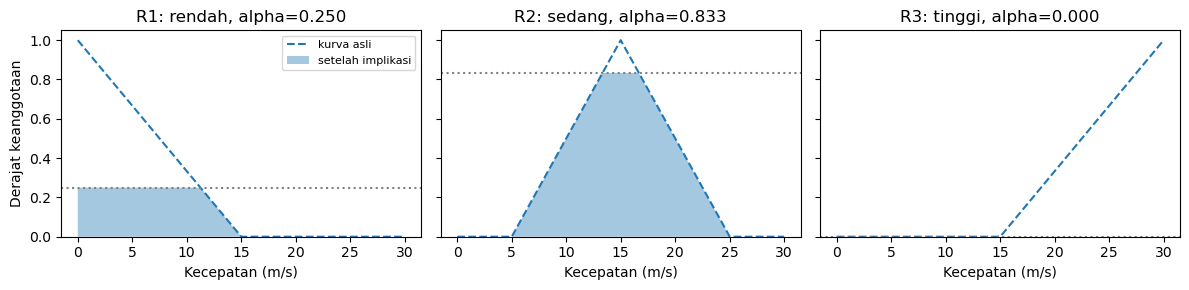

In [9]:
speed_grid = np.linspace(0, 30, 3001)  # langkah 0,01 m/s
output_curves = {
    "rendah": np.array([linear_down(z, 0, 15) for z in speed_grid]),
    "sedang": np.array([triangular(z, 5, 15, 25) for z in speed_grid]),
    "tinggi": np.array([linear_up(z, 15, 30) for z in speed_grid]),
}
clipped_outputs = np.array([
    np.minimum(alpha, output_curves[rule["output"]])
    for rule, alpha in zip(rules, strengths)
])
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, rule, alpha, clipped in zip(axes, rules, strengths, clipped_outputs):
    ax.plot(speed_grid, output_curves[rule["output"]], "--", label="kurva asli")
    ax.fill_between(speed_grid, clipped, alpha=0.4, label="setelah implikasi")
    ax.axhline(alpha, color="gray", linestyle=":")
    ax.set_title(f'{rule["aturan"]}: {rule["output"]}, alpha={alpha:.3f}')
    ax.set_xlabel("Kecepatan (m/s)")
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("Derajat keanggotaan")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Kurva rendah terpotong pada 0,25 dan kurva sedang pada sekitar 0,8333. Keluaran R3 seluruhnya nol. Kurva hasil R1/R2 masih mencakup banyak kecepatan, sehingga kita belum mempunyai satu angka rekomendasi.

---
## 2.5 Langkah 4: agregasi keluaran aturan

### Penjelasan

**Agregasi** menggabungkan kurva keluaran aturan dengan maksimum pada **setiap titik kecepatan**:

$$\mu_{\mathrm{agg}}(z)=\max_i\mu'_i(z).$$

Pada $z=10$ m/s, kontribusi R1, R2, dan R3 adalah [0,25; 0,5; 0], sehingga derajat gabungannya 0,5. Pada titik lain, aturan yang membentuk batas atas dapat berbeda. Oleh karena itu, mengambil satu aturan dengan alpha terbesar saja tidak sama dengan melakukan agregasi.

![Pemotongan dan agregasi dua aturan pada halaman 45 Fuzzy Logic complete.pdf](img/complete-45-mamdani.png)

Dua operasi min/max mempunyai tempat berbeda: min pada implikasi membatasi **satu** kurva, sedangkan max pada agregasi menggabungkan kurva **antaraturan**.

### Contoh penerapan

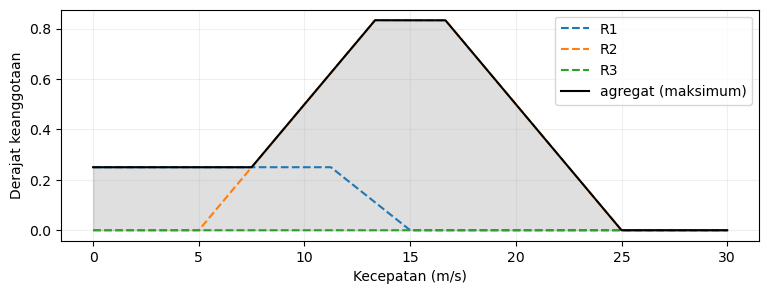

Kontribusi pada 10 m/s: [0.25 0.5  0.  ]
Agregat pada 10 m/s: 0.5


In [10]:
aggregated = np.maximum.reduce(clipped_outputs)
plt.figure(figsize=(9, 3))
for rule, clipped in zip(rules, clipped_outputs):
    plt.plot(speed_grid, clipped, "--", label=rule["aturan"])
plt.fill_between(speed_grid, aggregated, color="gray", alpha=0.25)
plt.plot(speed_grid, aggregated, color="black", label="agregat (maksimum)")
plt.xlabel("Kecepatan (m/s)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
index_10 = np.argmin(abs(speed_grid - 10))
print("Kontribusi pada 10 m/s:", clipped_outputs[:, index_10])
print("Agregat pada 10 m/s:", aggregated[index_10])

Batas atas daerah abu-abu adalah satu himpunan fuzzy keluaran. Bagian kecepatan rendah dari R1 tetap ikut membentuk daerah ini. Penjumlahan kurva bukan operator agregasi yang digunakan dalam contoh.

---
## 2.6 Langkah 5: defuzzifikasi dengan centroid

### Penjelasan

Sistem yang membutuhkan angka tindakan perlu mengubah kurva agregat menjadi **output crisp**. Metode **centroid** atau *center of gravity* (COG/COA) mencari titik keseimbangan luas di bawah kurva:

$$z^*=\frac{\int_{z_{\min}}^{z_{\max}}z\,\mu_{\mathrm{agg}}(z)\,dz}
{\int_{z_{\min}}^{z_{\max}}\mu_{\mathrm{agg}}(z)\,dz}.$$

Penyebut adalah luas total; pembilang adalah momen luas terhadap titik nol. Daerah pada nilai $z$ lebih besar menarik titik keseimbangan ke kanan. Semua bagian kurva berkontribusi, termasuk bagian yang derajatnya kecil.

Kode memakai integrasi numerik trapesium pada grid berjarak 0,01 m/s. Nilai yang diperoleh merupakan pendekatan centroid kurva kontinu. Pada domain diskret dengan bobot titik yang sama, bentuknya menjadi $\sum_j z_j\mu_j/\sum_j\mu_j$.

**Jangan langsung merata-ratakan puncak label menggunakan alpha.** Pada Mamdani max-min, bentuk, luas, dan tumpang tindih kurva terpotong ikut menentukan centroid. Contoh ringkas PDF halaman 75 dan 86 memakai nilai perwakilan kategori; rumus ringkas itu tidak secara umum sama dengan centroid kurva agregat yang dihitung di sini.

Metode lain dapat memberi hasil berbeda: **bisector (BOA)** membagi luas menjadi dua sama besar; **MOM** merata-ratakan posisi yang mencapai maksimum; **SOM** mengambil posisi maksimum terkecil; **LOM** mengambil yang terbesar. Centroid adalah titik keseimbangan, sehingga tidak harus membagi luas menjadi dua sama besar.

### Contoh penerapan

Luas agregat: 11.2847
Rekomendasi kecepatan: 13.36 m/s


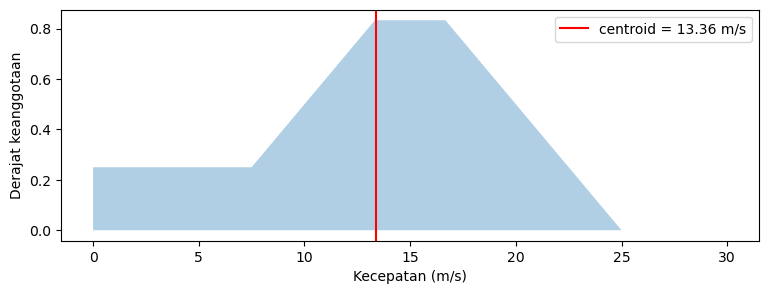

In [11]:
def integrate_trapezoids(values, grid):
    # Luas setiap trapesium = lebar * rata-rata tinggi kedua ujung.
    return float(np.sum(np.diff(grid) * (values[:-1] + values[1:]) / 2))

def centroid(grid, membership):
    area = integrate_trapezoids(membership, grid)
    if area <= 0:
        raise ValueError("Tidak ada keluaran aktif; periksa domain dan cakupan aturan.")
    moment = integrate_trapezoids(grid * membership, grid)
    return moment / area

crisp_speed = centroid(speed_grid, aggregated)
print(f"Luas agregat: {integrate_trapezoids(aggregated, speed_grid):.4f}")
print(f"Rekomendasi kecepatan: {crisp_speed:.2f} m/s")
plt.figure(figsize=(9, 3))
plt.fill_between(speed_grid, aggregated, alpha=0.35)
plt.axvline(crisp_speed, color="red", label=f"centroid = {crisp_speed:.2f} m/s")
plt.xlabel("Kecepatan (m/s)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.show()

Hasilnya sekitar **13,36 m/s**, di bawah pusat label sedang (15 m/s), karena kontribusi kecepatan rendah ikut menarik centroid ke kiri. Nilai ini berasal dari rancangan fungsi output praktikum, sehingga tidak ditujukan untuk menyamai angka kecepatan pada slide. Output crisp juga tidak harus sama dengan salah satu puncak fungsi keanggotaan.

---
## 2.7 Pengayaan: pemotongan dan penskalaan

### Penjelasan

PDF halaman 42-47 membandingkan pemotongan (*truncated*) dan penskalaan (*scaled*) konsekuen. Pada pemotongan, implikasinya $\min(\alpha_i,\mu_{C_i}(z))$. Pada penskalaan, implikasinya berupa perkalian:

$$\mu'_i(z)=\alpha_i\,\mu_{C_i}(z).$$

Dengan penskalaan, semua tinggi kurva dikalikan alpha. Misalnya, untuk alpha = 0,25 dan derajat kurva asli = 0,4, hasil pemotongan adalah 0,25, sedangkan hasil penskalaan adalah 0,1. Bentuk relatif kurva dipertahankan oleh penskalaan.

Pada perbandingan berikut, input, kekuatan aturan, fungsi output, dan agregasi max tetap sama; yang dibandingkan adalah pilihan **implikasi**. Perkalian pada implikasi berbeda letaknya dari perkalian sebagai alternatif operator AND pada anteseden.

### Contoh penerapan

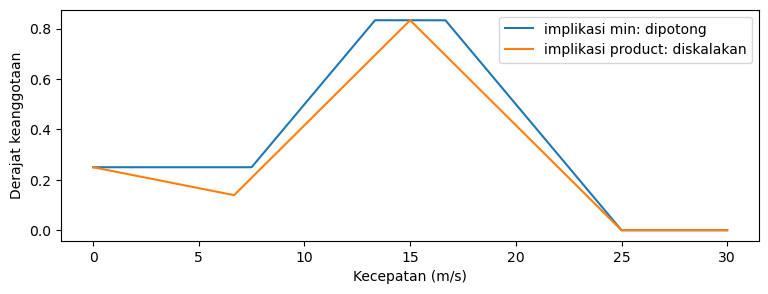

min + max        13.361538
product + max    13.475262
Name: centroid (m/s), dtype: float64

In [14]:
scaled_outputs = np.array([
    alpha * output_curves[rule["output"]]
    for rule, alpha in zip(rules, strengths)
])
scaled_aggregate = np.maximum.reduce(scaled_outputs)
plt.figure(figsize=(9, 3))
plt.plot(speed_grid, aggregated, label="implikasi min: dipotong")
plt.plot(speed_grid, scaled_aggregate, label="implikasi product: diskalakan")
plt.xlabel("Kecepatan (m/s)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.show()
display(pd.Series({
    "min + max": centroid(speed_grid, aggregated),
    "product + max": centroid(speed_grid, scaled_aggregate),
}, name="centroid (m/s)"))

Pemotongan menghasilkan sekitar **13,36 m/s**, sedangkan penskalaan menghasilkan sekitar **13,48 m/s**. Perubahan bentuk daerah keluaran dapat menggeser centroid walaupun alpha sama. Karena itu, saat melaporkan hasil inferensi, sebutkan fungsi keanggotaan, operator anteseden, implikasi, agregasi, dan metode defuzzifikasinya.

---
## 2.8 Aplikasi utuh: menguji beberapa jarak

### Penjelasan

Gabungkan langkah-langkah tadi ke satu fungsi. Fungsi ini mengembalikan derajat input, kekuatan aturan, kurva agregat, dan output crisp sehingga hasil antara tetap dapat diperiksa.

Sebelum menjalankan kode, buat prediksi: pada jarak 0 m hanya aturan rendah aktif; pada 5 m hanya aturan sedang aktif; pada 10 m hanya aturan tinggi aktif. Karena fungsi rendah memiliki luas pada rentang 0-15 m/s, centroidnya bukan otomatis 0 m/s. Inilah contoh bagaimana definisi himpunan output memengaruhi perilaku sistem.

Periksa juga input di sekitar daerah tumpang tindih. Perubahan kecepatan ditentukan bersama oleh fungsi input, bentuk output, dan interaksi aturan. Pada masalah nyata, definisi ini perlu disesuaikan dengan kebutuhan tindakan, misalnya kebutuhan berhenti ketika jarak sangat dekat.

### Contoh penerapan

,jarak (m),dekat,sedang,jauh,kecepatan (m/s)
0,0.0,1.00,0.0000,0.00,5.0000
1,2.5,0.75,0.5000,0.00,10.3805
2,3.5,0.25,0.8333,0.00,13.3615
3,5.0,0.00,1.0000,0.00,15.0000
4,7.5,0.00,0.5000,0.75,19.6195
5,10.0,0.00,0.0000,1.00,25.0000


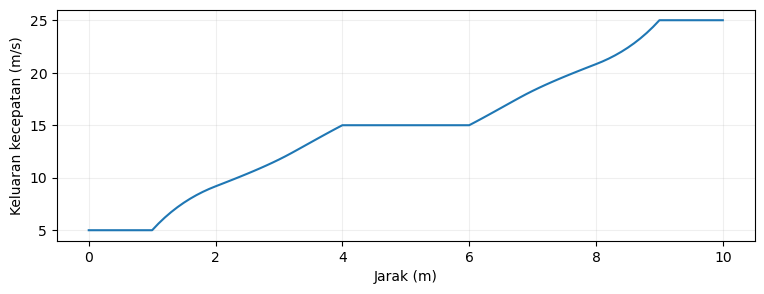

In [13]:
def mamdani_speed(distance):
    degrees = fuzzify_distance(distance)
    alphas = np.array([degrees[rule["input"]] for rule in rules])
    outputs = np.array([
        np.minimum(alpha, output_curves[rule["output"]])
        for rule, alpha in zip(rules, alphas)
    ])
    combined = np.maximum.reduce(outputs)
    return {
        "input_degrees": degrees,
        "strengths": alphas,
        "aggregated": combined,
        "speed": centroid(speed_grid, combined),
    }

rows = []
for x in [0, 2.5, 3.5, 5, 7.5, 10]:
    result = mamdani_speed(x)
    rows.append({"jarak (m)": x, **result["input_degrees"], "kecepatan (m/s)": result["speed"]})
display(pd.DataFrame(rows).round(4))
trial_distances = np.linspace(0, 10, 101)
plt.figure(figsize=(9, 3))
plt.plot(trial_distances, [mamdani_speed(x)["speed"] for x in trial_distances])
plt.xlabel("Jarak (m)")
plt.ylabel("Keluaran kecepatan (m/s)")
plt.grid(alpha=0.2)
plt.show()

Pada jarak 0, 5, dan 10 m, keluaran berturut-turut mendekati **5, 15, dan 25 m/s**. Saat beberapa aturan aktif, centroid memperhitungkan seluruh daerah gabungan. Fungsi menolak input di luar 0-10 m, dan perhitungan centroid menolak luas nol; hasil tidak diganti sembarang angka ketika aturan tidak mencakup input.

---
## Latihan Soal

Selesaikan tiga kasus berikut dengan **metode Mamdani**. Parameter dan aturan merupakan rancangan simulasi untuk latihan. Setiap kasus sudah menyediakan input crisp, domain, fungsi keanggotaan, serta basis aturan agar dapat diselesaikan sampai memperoleh output numerik.

**Ketentuan untuk semua kasus:** gunakan AND = min, OR = max, NOT = $1-\mu$, implikasi = min, agregasi = max, dan defuzzifikasi = centroid. Operator OR dan NOT digunakan jika tercantum pada aturan. Evaluasi fungsi keluaran hanya pada domain output yang diberikan.

Untuk setiap kasus, kerjakan tahapan berikut:

1. Gambarkan fungsi keanggotaan input dan output, lengkap dengan nama label dan satuannya.
2. Hitung fuzzifikasi input secara manual dan sajikan derajatnya dalam tabel.
3. Hitung kekuatan aktivasi setiap aturan; tunjukkan aturan yang aktif maupun tidak aktif.
4. Terapkan implikasi min pada kurva konsekuen setiap aturan, lalu gabungkan seluruh hasilnya dengan max.
5. Gambarkan kurva agregat dan hitung centroid menggunakan grid output dengan jarak antartitik **0,1**, termasuk kedua batas domain. Gunakan integrasi trapesium seperti fungsi `centroid` pada materi.
6. Sajikan output crisp dengan satuan yang sesuai, lalu jelaskan hubungannya dengan input dan aturan yang dominan.

Gunakan fungsi keanggotaan dari `membership.py` dan fungsi `centroid` yang telah tersedia. Susun perhitungan inferensi sesuai data setiap kasus. Tulis jawaban pada sel kosong; tambahkan sel Markdown atau kode jika diperlukan. Hint tersedia sebagai petunjuk pengerjaan tanpa jawaban akhir.

### Soal 1 - Kasus pengaturan kecepatan kipas

Sebuah pengendali menentukan persentase kecepatan kipas berdasarkan suhu ruangan. Pada saat pengukuran, suhu ruangan adalah **28°C**. Tentukan rekomendasi kecepatan kipas menggunakan seluruh tahapan Mamdani.

**Input:** suhu $T$ dengan domain [10,45] °C.

| Label suhu | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Nyaman | `triangular(T, 20, 30, 40)` |
| Panas | `linear_up(T, 30, 40)` |

**Output:** kecepatan kipas $z$ dengan domain [0,100] persen dari kecepatan maksimum.

| Label kecepatan | Fungsi keanggotaan |
|---|---|
| Lambat | `linear_down(z, 0, 50)` |
| Sedang | `triangular(z, 25, 50, 75)` |
| Cepat | `linear_up(z, 50, 100)` |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF suhu Sejuk | THEN kecepatan Lambat |
| R2 | IF suhu Nyaman | THEN kecepatan Sedang |
| R3 | IF suhu Panas | THEN kecepatan Cepat |

Setelah menyelesaikan input 28°C, ulangi perhitungan untuk **36°C** dengan model yang sama. Bandingkan aturan aktif, bentuk kurva agregat, dan output crisp kedua kondisi. Jelaskan apakah perubahan rekomendasinya sesuai dengan maksud basis aturan.

<details>
<summary>Klik untuk melihat hint</summary>

Letakkan suhu input pada masing-masing kurva sebelum memilih cabang rumus. Karena setiap aturan hanya mempunyai satu syarat, telusuri langsung derajat label pada antesedennya. Untuk membandingkan kedua kondisi, perhatikan posisi daerah keluaran yang terbentuk setelah pemotongan, bukan hanya tinggi maksimum kurvanya.

</details>

### Soal 2 - Kasus penentuan durasi pencucian

Sebuah mesin cuci menentukan durasi pencucian dari tingkat kekotoran dan berat pakaian. Sensor menunjukkan **indeks kekotoran 65** dan **berat pakaian 6,5 kg**. Tentukan durasi pencucian dengan Mamdani menggunakan seluruh tahapan pada petunjuk latihan.

**Input pertama:** indeks kekotoran $k$ dengan domain [0,100]. Indeks 0 menyatakan tingkat kekotoran terendah dan 100 tertinggi; indeks ini tidak memiliki satuan fisik.

| Label kekotoran | Fungsi keanggotaan |
|---|---|
| Rendah | `linear_down(k, 20, 50)` |
| Sedang | `trapezoidal(k, 20, 40, 60, 80)` |
| Tinggi | `linear_up(k, 50, 80)` |

**Input kedua:** berat pakaian $b$ dengan domain [0,10] kg.

| Label berat | Fungsi keanggotaan |
|---|---|
| Ringan | `linear_down(b, 2, 5)` |
| Sedang | `triangular(b, 2, 5, 8)` |
| Berat | `linear_up(b, 5, 8)` |

**Output:** durasi pencucian $z$ dengan domain [0,60] menit.

| Label durasi | Fungsi keanggotaan |
|---|---|
| Singkat | `linear_down(z, 10, 30)` |
| Normal | `trapezoidal(z, 15, 25, 35, 45)` |
| Lama | `linear_up(z, 30, 50)` |

**Basis aturan:** setiap sel tabel menyatakan konsekuen untuk kombinasi **kekotoran AND berat pakaian**. Baris menunjukkan label kekotoran dan kolom menunjukkan label berat pakaian, sehingga terdapat sembilan aturan.

| Kekotoran / Berat pakaian | Ringan | Sedang | Berat |
|---|---|---|---|
| Rendah | Singkat | Singkat | Normal |
| Sedang | Singkat | Normal | Lama |
| Tinggi | Normal | Lama | Lama |

Beri nama R1-R9 secara berurutan dari kiri ke kanan pada setiap baris, mulai baris Rendah. Sajikan alpha untuk kesembilan aturan. Bila beberapa aturan memiliki konsekuen yang sama, tunjukkan bagaimana kontribusinya digabungkan.

Setelah memperoleh durasi untuk kondisi awal, ulangi perhitungan dengan **indeks kekotoran 35** dan berat tetap **6,5 kg**. Bandingkan kedua durasi dan jelaskan pengaruh perubahan input melalui aturan yang aktif.

<details>
<summary>Klik untuk melihat hint</summary>

Hitung derajat kekotoran dan berat secara terpisah, lalu pasangkan sesuai baris dan kolom tabel aturan. Gunakan operator AND pada setiap pasangan derajat. Saat beberapa aturan mengarah ke label output yang sama, kembali ke definisi agregasi max pada setiap titik domain; hindari menjumlahkan alpha. Gunakan grid durasi yang sama saat membandingkan dua kondisi.

</details>

### Soal 3 - Kasus pengaturan durasi penyiraman

Sebuah sistem penyiraman menentukan lama penyiraman dari kelembapan tanah dan suhu udara. Sensor menunjukkan **kelembapan tanah 45%** dan **suhu udara 32°C**. Tentukan durasi penyiraman dengan Mamdani. Kasus ini menggunakan AND, OR, dan NOT pada anteseden.

**Input pertama:** kelembapan tanah $h$ dengan domain [0,100] persen.

| Label kelembapan | Fungsi keanggotaan |
|---|---|
| Kering | `linear_down(h, 30, 60)` |
| Cukup | `trapezoidal(h, 30, 45, 60, 75)` |
| Basah | `linear_up(h, 60, 80)` |

**Input kedua:** suhu udara $T$ dengan domain [15,40] °C.

| Label suhu | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Panas | `linear_up(T, 25, 35)` |

**Output:** durasi penyiraman $z$ dengan domain [0,30] menit.

| Label durasi | Fungsi keanggotaan |
|---|---|
| Singkat | `linear_down(z, 0, 15)` |
| Sedang | `triangular(z, 5, 15, 25)` |
| Lama | `linear_up(z, 15, 30)` |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF tanah Kering AND suhu Panas | THEN durasi Lama |
| R2 | IF tanah Kering AND NOT (suhu Panas) | THEN durasi Sedang |
| R3 | IF tanah Cukup AND suhu Panas | THEN durasi Sedang |
| R4 | IF tanah Cukup AND NOT (suhu Panas) | THEN durasi Singkat |
| R5 | IF tanah Basah OR suhu Sejuk | THEN durasi Singkat |

Selesaikan seluruh tahapan Mamdani dan tuliskan operasi anteseden setiap aturan secara eksplisit. Untuk R2 dan R4, NOT hanya diterapkan pada kondisi suhu Panas.

Kemudian ubah **suhu menjadi 27°C**, dengan kelembapan tetap **45%**. Hitung ulang hasilnya. Bandingkan kekuatan R2, R4, dan R5 serta jelaskan kontribusinya terhadap perubahan durasi. Berdasarkan fungsi yang diberikan, periksa pula apakah label Sejuk selalu sama dengan NOT Panas pada seluruh domain suhu.

<details>
<summary>Klik untuk melihat hint</summary>

Evaluasi fungsi Panas terlebih dahulu sebelum menggunakan komplemennya. Hitung fungsi Sejuk secara terpisah berdasarkan parameternya; kesamaan makna dalam bahasa sehari-hari belum cukup untuk menyamakan dua fungsi. Setelah evaluasi AND/OR, semua aturan tetap melalui implikasi min dan agregasi max yang sama. Untuk memeriksa kesetaraan dua fungsi, bandingkan grafiknya pada seluruh domain, bukan hanya satu suhu.

</details>